---
title: "CloriNN manuscript figures - softImpute benchmark"
author: "Saikat Banerjee"
format:
  html: default
date: "2026-02-16"
file-modified: "2026-02-16"
abstract: "High quality plots used for softImpute benchmark figures, using manuscript color palette."

---

In [1]:
import numpy as np
import pandas as pd
import pickle
import sys
import os
import dsc
from dsc.query_engine import Query_Processor as dscQP
from dsc import dsc_io

import matplotlib
import matplotlib.pyplot as plt
from pymir import mpl_stylesheet
from pymir import mpl_utils

In [2]:
# import matplotlib.font_manager as mpl_fm
# font_path = '/gpfs/commons/home/sbanerjee/nygc/Futura'
# mpl_fm.fontManager.addfont(font_path + '/FuturaStd-Book.otf') # Loads "Futura Std"

# mpl_stylesheet.banskt_presentation(splinecolor = 'black', dpi = 300)
# futura_book = FontProperties(fname='/gpfs/commons/home/sbanerjee/nygc/Futura/FuturaStd-Book.otf')

manuscript_colors = {
    'brown': '#7F180D',
    'darkred': '#C10020',
    'darkyellow': '#FF6800',
    'blue': '#00538A',
    'green': '#0A8A42',
    'lightgreen': '#74B74A',    
    'yellowgreen': '#93AA00',
    'lightblue': '#A6BDD7',
    'purple': '#803E75',
    'olive': '#232C16',
    'khaki': '#CEA262',
    'darkgray': '#1A1A1A',
    'orange': '#F37239',
}

# Style sheet for manuscript
mpl_stylesheet.banskt_presentation(dpi = 300, fontsize = 22, 
    splinecolor = manuscript_colors['darkgray'], black = manuscript_colors['darkgray'])
# plt.rcParams['font.family'] = 'Futura Std'

In [5]:
dsc_output = "/gpfs/commons/groups/knowles_lab/sbanerjee/low_rank_matrix_approximation_numerical_experiments/mc_benchmark"
dsc_fname  = os.path.basename(os.path.normpath(dsc_output))
db = os.path.join(dsc_output, dsc_fname + ".db")
dscoutpkl = os.path.join("/gpfs/commons/home/sbanerjee/work/npd/lrma-dsc/dsc/results", dsc_fname + "_dscout.pkl")
dscout    = pd.read_pickle(dscoutpkl)

dscout = dscout.rename(columns={
    "mcmethods.n_iter": "score.n_iter",
    "mcmethods.time_sec": "score.time_sec"
})

dscout["score.time_per_iter"] = dscout["score.time_sec"] / dscout["score.n_iter"]

dscout

,DSC,input_with_nan.n,input_with_nan.p,input_with_nan.k,input_with_nan.h2,input_with_nan.h2_shared_frac,input_with_nan.aq,input_with_nan.nsample_minmax,input_with_nan.missing_ratio,mcmethods,score.n_iter,score.time_sec,score.test_rmse,score.time_per_iter
0,1,200,2000,10,0.2,0.4,0.6,"(10000,40000)",0.05,frankwolfe,576,130.586818,1.755165,0.226713
1,1,200,2000,10,0.2,0.4,0.6,"(10000,40000)",0.10,frankwolfe,597,133.042829,1.752237,0.222852
2,1,200,2000,10,0.2,0.4,0.6,"(10000,40000)",0.20,frankwolfe,714,143.325775,1.779257,0.200736
3,1,200,2000,10,0.2,0.4,0.6,"(10000,40000)",0.40,frankwolfe,761,164.217400,1.743727,0.215792
4,2,200,2000,10,0.2,0.4,0.6,"(10000,40000)",0.05,frankwolfe,622,143.336019,1.721939,0.230444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,9,200,2000,10,0.2,0.4,0.6,"(10000,40000)",0.40,softimpute,3,0.705388,1.740518,0.235129
76,10,200,2000,10,0.2,0.4,0.6,"(10000,40000)",0.05,softimpute,8,1.190660,1.717270,0.148833
77,10,200,2000,10,0.2,0.4,0.6,"(10000,40000)",0.10,softimpute,6,0.440634,1.829446,0.073439
78,10,200,2000,10,0.2,0.4,0.6,"(10000,40000)",0.20,softimpute,20,1.916495,1.802666,0.095825


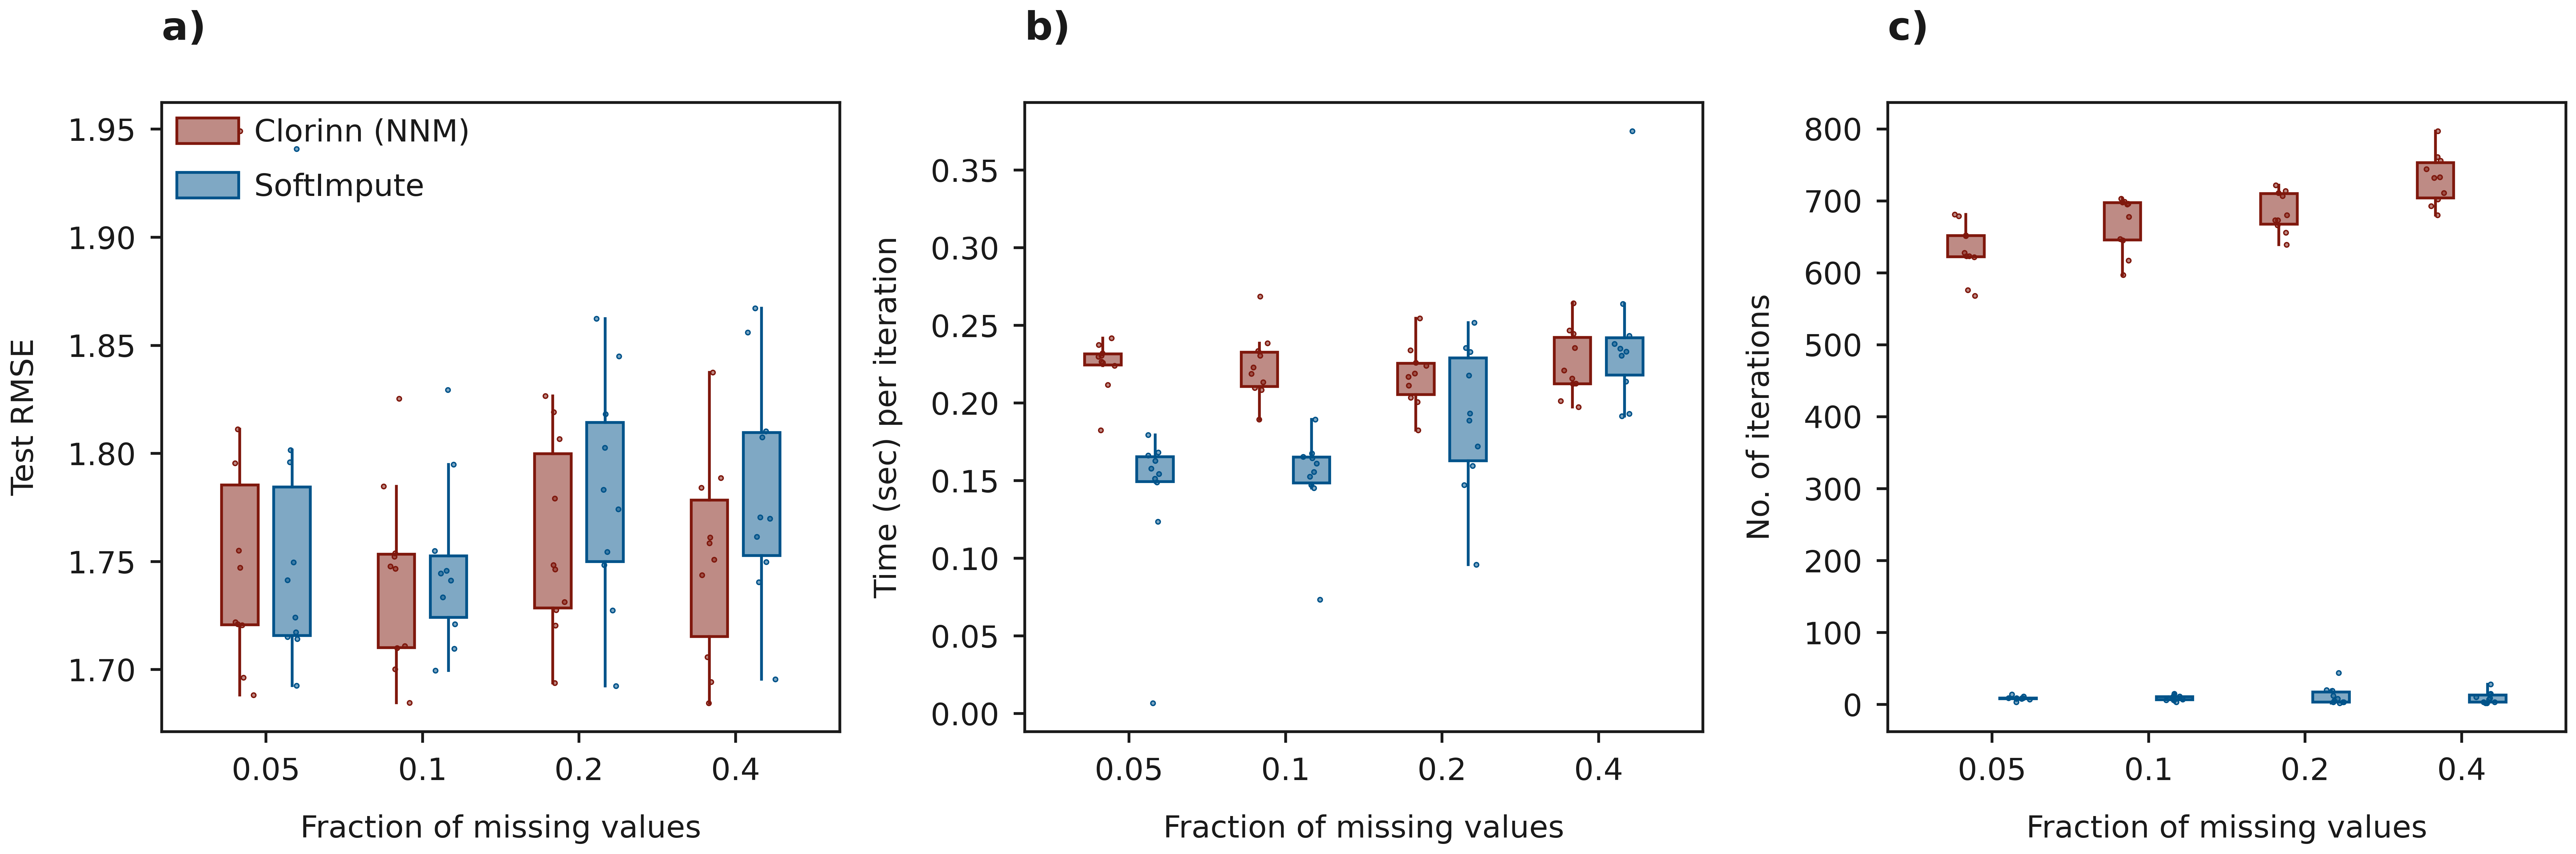

In [17]:
def stratify_dfcol(df, colname, value):
    #return pd_utils.select_dfrows(df, [f"$({colname}) == {value}"])
    if value is None:
        return df.loc[df[colname].isnull()]
    else:
        return df.loc[df[colname] == value]

def stratify_dfcols(df, condition_list):
    for (colname, value) in condition_list:
        df = stratify_dfcol(df, colname, value)
    return df

def stratify_dfcols_in_list(df, colname, values):
    return df.loc[df[colname].isin(values)]


method_labels = {
    "frankwolfe" : "Clorinn (NNM)",
    "softimpute": "SoftImpute",
}

method_colors = {
    "frankwolfe" : manuscript_colors['brown'],
    "softimpute" : manuscript_colors['blue'],
}

# Base parameters
simparams = {'p': 2000, 'k': 10, 'h2': 0.2, 'h2_shared_frac': 0.4, 'aq': 0.6}
score_names = {
    'test_rmse': "Test RMSE",
    'time_per_iter': "Time (sec) per iteration",
    'n_iter': "No. of iterations"
}
panel_labels = ["a)", "b)", "c)"]

def get_simulation_with_variable(df, var_name, var_values):
    condition = [(f'input_with_nan.{k}', v) for k, v in simparams.items() if k != var_name]
    df1 = stratify_dfcols(df, condition)
    df2 = stratify_dfcols_in_list(df1, f'input_with_nan.{var_name}', var_values)
    return df2

def get_scores_from_dataframe(df, score_name, variable_name, variable_values, 
        methods = method_labels.keys()):
    simdf = get_simulation_with_variable(df, variable_name, variable_values)
    scores = {key: list() for key in methods}
    for method in methods:
        mrows = stratify_dfcols(simdf, [('mcmethods', method)])
        # mrows = stratify_dfcols(simdf, [('lowrankfit', mlist[0]), ('mfmethods', mlist[1])])
        for value in variable_values:
            vrows = stratify_dfcol(mrows, f'input_with_nan.{variable_name}', value)
            scores[method].append(vrows[f'score.{score_name}'].to_numpy())
    return scores

def random_jitter(xvals, yvals, d = 0.1):
    xjitter = [x + np.random.randn(len(y)) * d for x, y in zip(xvals, yvals)]
    return xjitter

def boxplot_scores(variable, variable_values, 
        methods = method_labels.keys(), score_names = score_names,
        dscout = dscout, method_colors = method_colors,
        panel_labels = None,
        custom_font = 'Futura Std', xlabel = "Fraction of missing values"):
    
    nmethods = len(methods)
    nvariables = len(variable_values)
    nscores = len(score_names)
    
    figh = 8
    figw = (nscores * figh) + (nscores - 1)
    fig = plt.figure(figsize = (figw, figh + 1))
    axs = [fig.add_subplot(1, nscores, x+1) for x in range(nscores)]
    boxs = {x: None for x in methods}
    
    for i, (score_name, score_label) in enumerate(score_names.items()):
        scores = get_scores_from_dataframe(dscout, score_name, variable, variable_values)
        for j, mkey in enumerate(methods):
            boxcolor = method_colors[mkey]
            boxface = f'#{boxcolor[1:]}80'
            medianprops = dict(linewidth=0, color = boxcolor)
            whiskerprops = dict(linewidth=2, color = boxcolor)
            boxprops = dict(linewidth=2, color = boxcolor, facecolor = boxface)
            flierprops = dict(marker='o', markerfacecolor=boxface, markersize=3, markeredgecolor = boxcolor)

            xpos = [x * (nmethods + 1) + j for x in range(nvariables)]
            boxs[mkey] = axs[i].boxplot(scores[mkey], positions = xpos,
                showcaps = False, showfliers = False,
                widths = 0.7, patch_artist = True, notch = False,
                flierprops = flierprops, boxprops = boxprops,
                medianprops = medianprops, whiskerprops = whiskerprops)
            
            axs[i].scatter(random_jitter(xpos, scores[mkey]), scores[mkey], 
                           edgecolor = boxcolor, facecolor = boxface, linewidths = 1, 
                           s = 10)

        xcenter = [x * (nmethods + 1) + (nmethods - 1) / 2 for x in range(nvariables)]
        axs[i].set_xticks(xcenter)
        axs[i].set_xticklabels(variable_values)
        axs[i].set_xlabel(xlabel)
        axs[i].set_ylabel(score_label)
        xlim_low = 0 - (nvariables - 1) / 2
        #xlim_high = (nvariables - 1) * (nmethods + 1) + (nmethods - 1) + (nvariables - 1) / 2
        xlim_high = (nmethods + 1.5) * nvariables - 2.5
        axs[i].set_xlim( xlim_low, xlim_high )
        
        if panel_labels is not None:
            axs[i].text(0, 1.1, panel_labels[i], transform=axs[i].transAxes, 
                        fontweight='bold', fontsize = 28)

    plt.tight_layout()
    return axs, boxs

variable = 'missing_ratio'
variable_values = [0.05, 0.1, 0.2, 0.4]

axs, boxs = boxplot_scores(variable, variable_values, panel_labels = panel_labels)

handles = [boxs[mkey]["boxes"][0] for mkey in method_labels.keys()]
labels = [method_labels[mkey] for mkey in method_labels.keys()]
axs[0].legend(handles = handles, labels = labels, 
           loc = 'upper left', frameon = False, handlelength = 2, ncol = 1)

# plt.tight_layout()
# plt.savefig('../plots/softimpute_benchmark_results.png', bbox_inches='tight')
plt.savefig('../plots/softimpute_benchmark_results.pdf', bbox_inches='tight')
plt.show()